<a href="https://colab.research.google.com/github/EktaSinghES/Machine_Learning_Lab-2547221/blob/LAB_ACTIVITY/Decision_Tree_Iris_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Activity: Decision Tree Classification on the Iris Dataset

**Dataset:** `sklearn.datasets.load_iris()`  
**Split:** 80% training and 20% testing, with `random_state=42`

This notebook completes Tasks 1–10. A fixed `random_state` is also used for the
experimental trees so that tie-breaking and all reported results are reproducible.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

## Task 1: Dataset Exploration

The Iris dataset contains **150 samples** and **4 input features**. Its three target
classes are setosa, versicolor, and virginica.

In [ ]:
iris = load_iris()
X, y = iris.data, iris.target

iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df["target"] = y
iris_df["class"] = pd.Categorical.from_codes(y, iris.target_names)

print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print("Feature names:", list(iris.feature_names))
print("Target classes:", list(iris.target_names))

print("\nFirst five records:")
display(iris_df.head())

print("Class distribution:")
class_distribution = iris_df["class"].value_counts(sort=False).rename("count").to_frame()
display(class_distribution)

Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,class
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Class distribution:


,count
class,
setosa,50
versicolor,50
virginica,50


## Task 2: Data Preparation

The training set is used to learn the decision rules. The testing set is kept unseen
during training and provides an independent estimate of how well the model generalizes
to new data. Using the same split throughout makes the experiments directly comparable.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set: ", X_test.shape, y_test.shape)

Training set: (120, 4) (120,)
Testing set:  (30, 4) (30,)


## Task 3: Building a Default Decision Tree Classifier

`DecisionTreeClassifier()` is trained with its default model hyperparameters. Setting
only `random_state=42` controls random tie-breaking and does not limit the tree.

In [ ]:
default_tree = DecisionTreeClassifier(random_state=42)
default_tree.fit(X_train, y_train)
y_pred = default_tree.predict(X_test)

default_accuracy = accuracy_score(y_test, y_pred)
default_cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy score: {default_accuracy:.4f}")
print("\nConfusion matrix:")
display(pd.DataFrame(
    default_cm,
    index=[f"Actual {name}" for name in iris.target_names],
    columns=[f"Predicted {name}" for name in iris.target_names],
))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy score: 1.0000

Confusion matrix:


,Predicted setosa,Predicted versicolor,Predicted virginica
Actual setosa,10,0,0
Actual versicolor,0,9,0
Actual virginica,0,0,11



Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



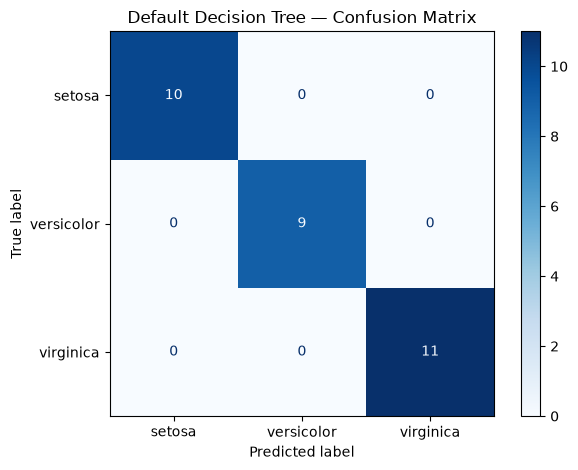

In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix=default_cm,
    display_labels=iris.target_names,
).plot(cmap="Blues")
plt.title("Default Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()

## Task 4: Visualizing and Interpreting the Decision Tree

- **Root node:** the top node, which makes the first split.
- **Internal nodes:** all non-leaf decision nodes below the root.
- **Leaf nodes:** terminal nodes with no children; each supplies a predicted class.
- **Maximum depth:** the greatest number of edges from the root to a leaf.

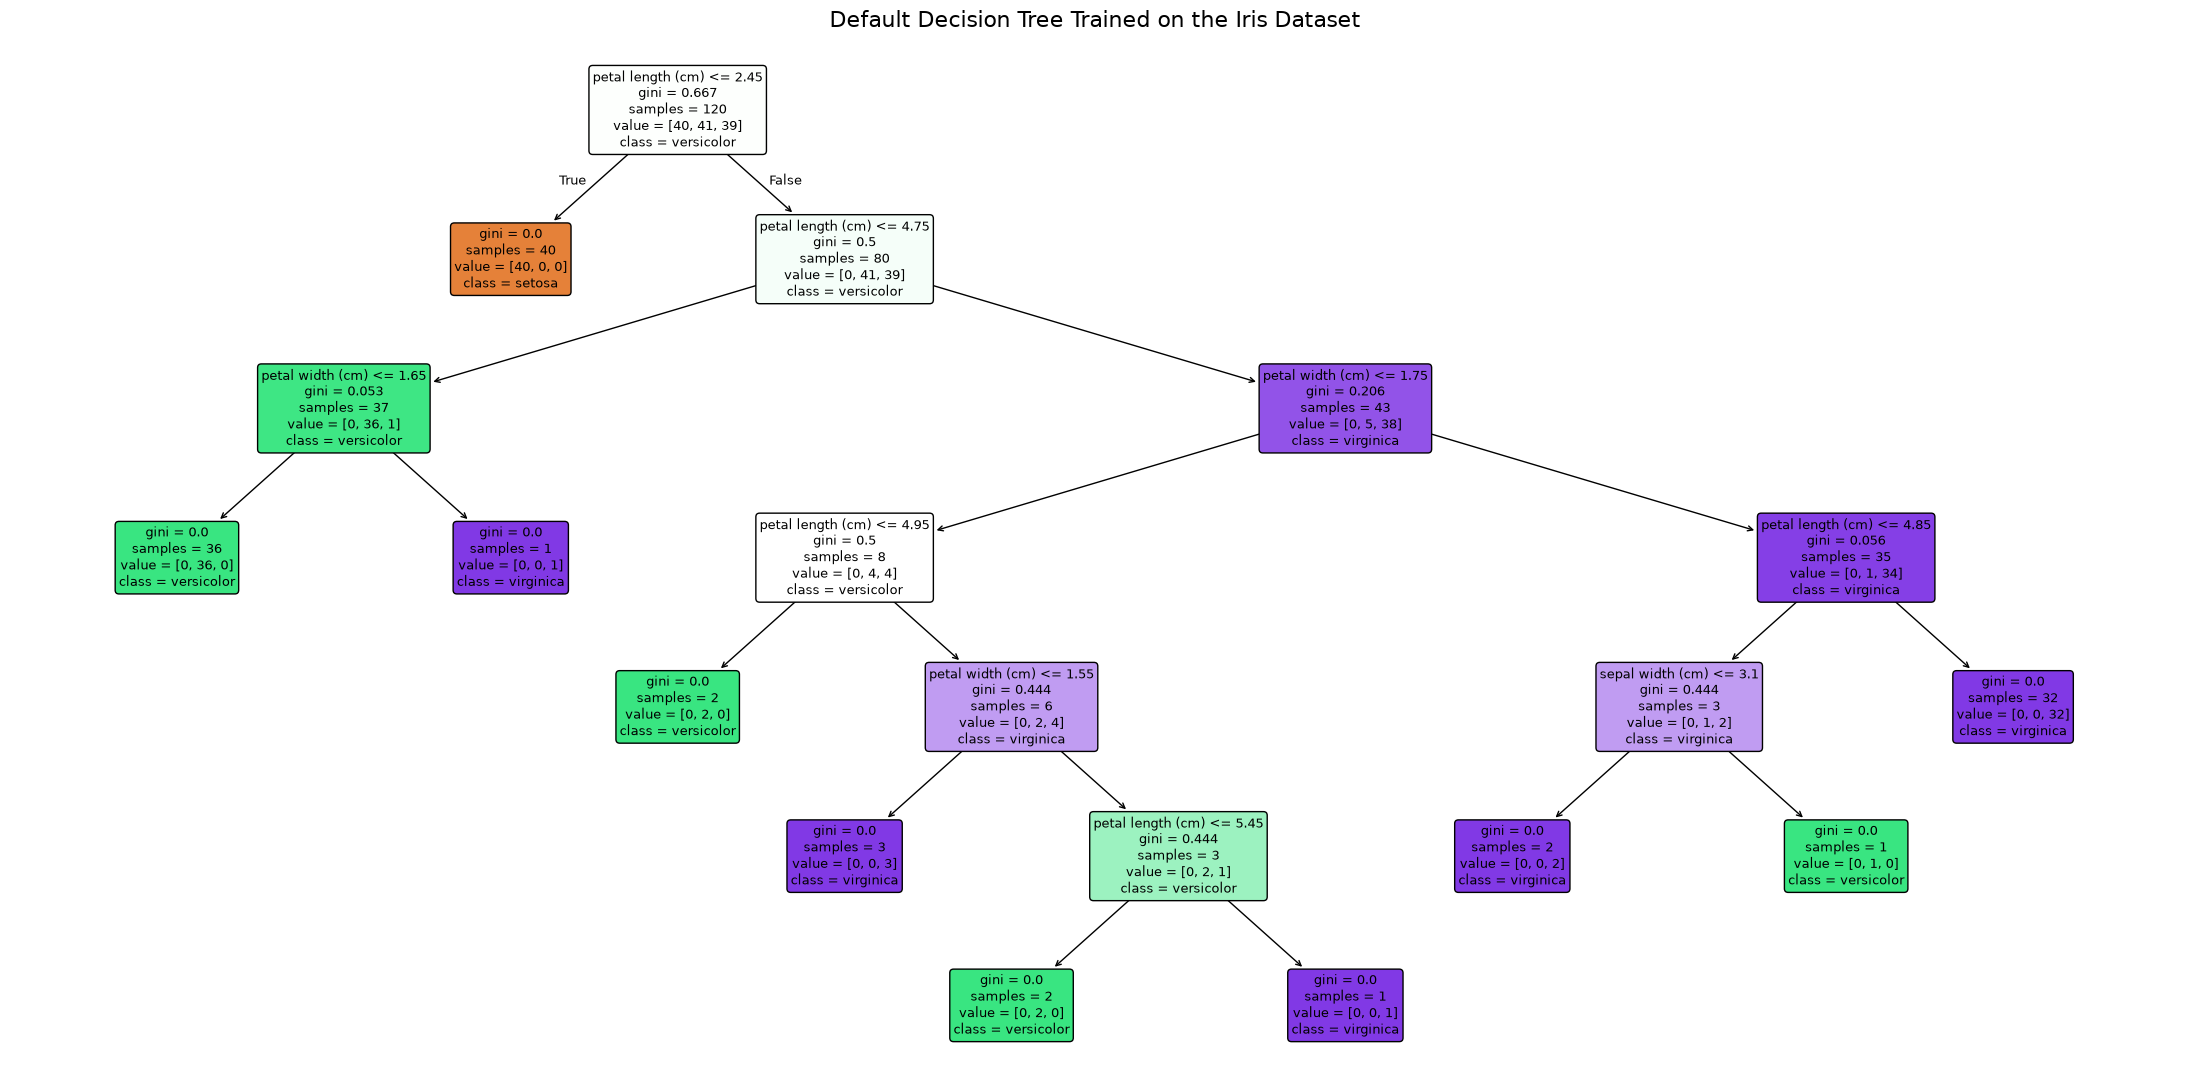

In [ ]:
plt.figure(figsize=(22, 11))
plot_tree(
    default_tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Default Decision Tree Trained on the Iris Dataset", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
tree_ = default_tree.tree_
root_feature = iris.feature_names[tree_.feature[0]]
root_threshold = tree_.threshold[0]
internal_nodes = int(np.sum(tree_.children_left != tree_.children_right))
leaf_nodes = default_tree.get_n_leaves()

print(f"Root node: {root_feature} <= {root_threshold:.2f} cm")
print(f"Number of internal nodes (including root): {internal_nodes}")
print(f"Number of leaf nodes: {leaf_nodes}")
print(f"Maximum tree depth: {default_tree.get_depth()}")
print(f"First split feature: {root_feature}")

Root node: petal length (cm) <= 2.45 cm
Number of internal nodes (including root): 9
Number of leaf nodes: 10
Maximum tree depth: 6
First split feature: petal length (cm)


The first split uses **petal length**. The algorithm considers candidate splits and
selects the one giving the largest reduction in impurity. Iris setosa has much shorter
petals than the other two classes, so petal length creates a very pure separation near
the root. The exact displayed threshold is learned from the training set.

## Task 5: Comparing Gini Index and Entropy

In [ ]:
criterion_rows = []
criterion_models = {}

for criterion in ["gini", "entropy"]:
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    model.fit(X_train, y_train)
    criterion_models[criterion] = model
    criterion_rows.append({
        "Criterion": criterion,
        "Accuracy": accuracy_score(y_test, model.predict(X_test)),
        "Tree depth": model.get_depth(),
        "Leaf nodes": model.get_n_leaves(),
        "Root feature": iris.feature_names[model.tree_.feature[0]],
    })

criterion_results = pd.DataFrame(criterion_rows)
display(criterion_results.style.format({"Accuracy": "{:.4f}"}))

,Criterion,Accuracy,Tree depth,Leaf nodes,Root feature
0,gini,1.0000,6,10,petal length (cm)
1,entropy,1.0000,6,10,petal length (cm)


Both criteria produce the same accuracy, depth, leaf count, and root feature on this
split. Therefore, **neither produces a simpler tree here**. Gini measures class mixing
using squared probabilities, while entropy uses information gain; either can produce a
different structure on other datasets or splits.

## Task 6: Effect of Maximum Tree Depth

In [ ]:
depth_rows = []
for requested_depth in [1, 2, 3, 4, None]:
    model = DecisionTreeClassifier(max_depth=requested_depth, random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    if requested_depth == 1:
        observation = "Underfits: one split cannot separate all three classes."
    elif requested_depth == 2:
        observation = "Simple tree with strong test performance."
    elif requested_depth == 3:
        observation = "Best generalization: perfect test accuracy with limited depth."
    elif requested_depth == 4:
        observation = "Perfect test accuracy, but more complex than depth 3."
    else:
        observation = "Fully grown; perfect training accuracy and highest complexity."

    depth_rows.append({
        "Max depth": str(requested_depth),
        "Training accuracy": train_acc,
        "Testing accuracy": test_acc,
        "Tree depth": model.get_depth(),
        "Observation": observation,
    })

depth_results = pd.DataFrame(depth_rows)
display(depth_results.style.format({
    "Training accuracy": "{:.4f}",
    "Testing accuracy": "{:.4f}",
}))

,Max depth,Training accuracy,Testing accuracy,Tree depth,Observation
0,1,0.6750,0.6333,1,Underfits: one split cannot separate all three classes.
1,2,0.9500,0.9667,2,Simple tree with strong test performance.
2,3,0.9583,1.0000,3,Best generalization: perfect test accuracy with limited depth.
3,4,0.9750,1.0000,4,"Perfect test accuracy, but more complex than depth 3."
4,None,1.0000,1.0000,6,Fully grown; perfect training accuracy and highest complexity.


- **Underfitting:** `max_depth=1`, because both training and testing accuracy are low.
- **Best generalization:** `max_depth=3`, because it reaches perfect test accuracy with
  less complexity than depths 4 or None.
- **Most likely to overfit:** `max_depth=None`. It grows to depth 6 and memorizes the
  training set (100% training accuracy). Its test result happens to be perfect on this
  small split, but the extra depth and leaves add variance without improving test
  accuracy over the depth-3 tree.

## Task 7: Effect of `min_samples_split`

In [ ]:
split_rows = []
for value in [2, 5, 10, 20]:
    model = DecisionTreeClassifier(min_samples_split=value, random_state=42)
    model.fit(X_train, y_train)
    split_rows.append({
        "min_samples_split": value,
        "Accuracy": accuracy_score(y_test, model.predict(X_test)),
        "Tree depth": model.get_depth(),
        "Leaf nodes": model.get_n_leaves(),
        "Observation": (
            "Default; most complex tested tree." if value == 2 else
            "Moderate pruning with unchanged test accuracy." if value == 5 else
            "Simpler tree; test accuracy remains unchanged."
        ),
    })

split_results = pd.DataFrame(split_rows)
display(split_results.style.format({"Accuracy": "{:.4f}"}))

,min_samples_split,Accuracy,Tree depth,Leaf nodes,Observation
0,2,1.0000,6,10,Default; most complex tested tree.
1,5,1.0000,5,8,Moderate pruning with unchanged test accuracy.
2,10,1.0000,4,6,Simpler tree; test accuracy remains unchanged.
3,20,1.0000,4,6,Simpler tree; test accuracy remains unchanged.


Increasing `min_samples_split` requires more samples before a node may split. This
blocks some small-sample branches, generally reducing depth and the number of leaves.
Here, values 10 and 20 produce the same tree size and preserve test accuracy.

## Task 8: Effect of `min_samples_leaf`

In [ ]:
leaf_rows = []
for value in [1, 2, 5, 10]:
    model = DecisionTreeClassifier(min_samples_leaf=value, random_state=42)
    model.fit(X_train, y_train)
    accuracy = accuracy_score(y_test, model.predict(X_test))
    leaf_rows.append({
        "min_samples_leaf": value,
        "Accuracy": accuracy,
        "Tree depth": model.get_depth(),
        "Leaf nodes": model.get_n_leaves(),
        "Observation": (
            "Default; most flexible tested tree." if value == 1 else
            "Moderate regularization; accuracy unchanged." if value in [2, 5] else
            "Strongest regularization; accuracy decreases slightly."
        ),
    })

leaf_results = pd.DataFrame(leaf_rows)
display(leaf_results.style.format({"Accuracy": "{:.4f}"}))

,min_samples_leaf,Accuracy,Tree depth,Leaf nodes,Observation
0,1,1.0000,6,10,Default; most flexible tested tree.
1,2,1.0000,5,8,Moderate regularization; accuracy unchanged.
2,5,1.0000,4,6,Moderate regularization; accuracy unchanged.
3,10,0.9667,4,6,Strongest regularization; accuracy decreases slightly.


A larger `min_samples_leaf` prevents leaves supported by very few training examples.
This reduces sensitivity to noise and therefore lowers overfitting risk. If set too
high, however, it can prevent useful class boundaries and cause underfitting; the small
accuracy drop at 10 illustrates that trade-off.

## Task 9: Hyperparameter Tuning with GridSearchCV

In [ ]:
parameter_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=parameter_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1,
)
grid_search.fit(X_train, y_train)

optimized_tree = grid_search.best_estimator_
optimized_test_accuracy = accuracy_score(y_test, optimized_tree.predict(X_test))

print("Best hyperparameter combination:", grid_search.best_params_)
print(f"Best 5-fold cross-validation score: {grid_search.best_score_:.4f}")
print(f"Optimized model test accuracy: {optimized_test_accuracy:.4f}")
print(f"Default model test accuracy:   {default_accuracy:.4f}")

comparison = pd.DataFrame([
    {
        "Model": "Default",
        "Test accuracy": default_accuracy,
        "Tree depth": default_tree.get_depth(),
        "Leaf nodes": default_tree.get_n_leaves(),
    },
    {
        "Model": "GridSearchCV optimized",
        "Test accuracy": optimized_test_accuracy,
        "Tree depth": optimized_tree.get_depth(),
        "Leaf nodes": optimized_tree.get_n_leaves(),
    },
])
display(comparison.style.format({"Test accuracy": "{:.4f}"}))

Best hyperparameter combination: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best 5-fold cross-validation score: 0.9583
Optimized model test accuracy: 1.0000
Default model test accuracy:   1.0000


,Model,Test accuracy,Tree depth,Leaf nodes
0,Default,1.0000,6,10
1,GridSearchCV optimized,1.0000,4,7


The optimized and default models have the same test accuracy on this split. The tuned
model is shallower and has fewer leaves, so it achieves the result with less complexity.
The cross-validation score is the mean validation accuracy across five folds of the
training data; it is a more stable selection measure than the single held-out test set.

## Task 10: Analysis

### 1. What is the role of the `criterion` parameter?

It defines how split quality is measured. `gini` minimizes Gini impurity, whereas
`entropy` maximizes information gain. At each node, the tree selects the feature and
threshold producing the greatest impurity reduction according to the chosen criterion.

### 2. How does `max_depth` influence underfitting and overfitting?

A very small maximum depth restricts the model too strongly and can underfit; depth 1
achieved only 0.6750 training and 0.6333 testing accuracy. Allowing more depth captures
useful class boundaries, but an unrestricted tree can model noise and increase
overfitting risk. Depth 3 was the smallest tested depth with perfect test accuracy.

### 3. Why do larger `min_samples_split` and `min_samples_leaf` values create simpler trees?

They require stronger sample support for new branches and terminal regions. Fewer nodes
are eligible to split, and tiny leaves cannot form, so the tree usually becomes
shallower and has fewer leaves.

### 4. Which hyperparameter had the greatest impact?

In these experiments, **`max_depth` had the clearest impact on predictive performance**:
test accuracy rose from 0.6333 at depth 1 to 0.9667 at depth 2 and 1.0000 at depth 3.
Changing the criterion did not alter accuracy or tree size. Increasing
`min_samples_split` from 2 to 20 reduced complexity without changing test accuracy,
while `min_samples_leaf` affected accuracy only at the largest tested value (10).

### 5. Recommended model

For a deliberately compact standalone model, use
`DecisionTreeClassifier(max_depth=3, random_state=42)`: it gives perfect test accuracy
with only depth 3, avoiding unnecessary growth. When selection must follow the stated
tuning protocol, use the **GridSearchCV best estimator** reported above; it also achieves
perfect test accuracy, is simpler than the default tree, and was selected using
five-fold cross-validation rather than the test set.

> **Note:** Iris is small, so one 30-sample test split cannot prove that a model will
> always score 100%. Cross-validation and preferring the simpler equally accurate model
> provide more cautious evidence.